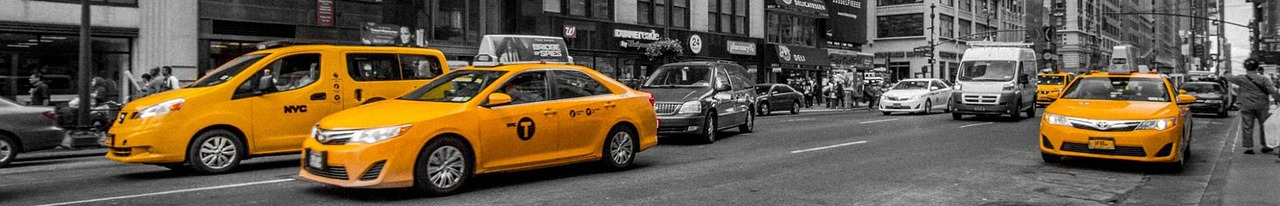

# 택시 이동시간 예측 AI 모델 개발 

## 개요
- 뉴욕시의 택시 운행별 이동시간(하차시간-승차시간) 예측
- https://softeer.ai/practice/11808
  
## 분석 배경
- 본 Competition은 뉴욕시 택시의 운행별 승차 시간을 예측하는 것입니다.
- 뉴욕 택시 리무진 위원회에서 발표한 주요 데이터 세트를 이용하며 여기에는 픽업 시간, 위도, 경도, 승객 수 및 기타 여러 변수가 포함되어 있습니다.
- 주어진 Feature 들을 이용하여 Taxi 운행 시간(duration)을 예측해 보세요.


## 평가 지표
- RMSLE : Root Mean Scaled Logarithmic Error
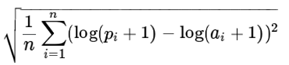

## 데이터 셋 정보

### [Data Files]
- train.csv: 학습용 데이터 (Features, Target) - 70,000여건     
- test.csv:  예측용 데이터 (Features) - 25,000여건
- sample_submission.csv: 제출용 파일

### [Feature]
- id:   승차 데이터별 식별자
- vendor_id:	제공자 코드
- pickup_datetime:	승차하여 미터기가 시작된 날짜 및 시간
- dropoff_datetime:	하차하여 미터기가 꺼진 날짜 및 시간 
    - **주의**: 이 변수는 train셋에만 있고 test셋에는 없음. 
    - 따라서 feature로 사용하지 못함!
- passenger_count:	승객 수
- pickup_longitude:	승차하여 미터기가 시작된 위치의 경도
- pickup_latitude:	승차하여 미터기가 시작된 위치의 위도
- dropoff_longitude:	하차하여 미터기가 꺼진 위치의 경도
- dropoff_latitude:	    하차하여 미터기가 꺼진 위치의 위도
- store_and_fwd_flag:	해당 trip record(승하차 기록)가 차량 메모리에 저장되었다가 서버에 전달되었는지 여부(차량은 서버와 직접 연결이 안됨)
       - Y = 차량 메모리에 저장되어 전달된 기록임
       - N = 차량 메모리에 저장되어 전달된 기록이 아님

### [Target]
- trip_duration:	이동 시간 (초)

## 분석 단계 
- **[step1] 라이브러리 및 데이터 불러오기** 
 - (1) 라이브러리 불러오기
 - (2) 데이터 불러오기 
 - (3) 데이터 확인 
 - **(4) 데이터 타입 변환 (필요시)** - month,day,hour,dow만 추출
- **[step2] 탐색적 데이터 분석 (EDA)**
 - (1) 기술적 통계분석
 - (2) 변수별 분포 시각화 
 - (3) **추가 변수 생성** (필요시) -distance
- **[step3] 데이터 전처리**
 - (1) 중복값 처리 **(Train셋만)**
 - (2) 불필요한 Feature삭제 (ID 등)
 - (3) 결측치 처리 
 - (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
 - (5) Feature, Target 설정
 - (6) 원핫 인코딩 **(feature-질적변수만)**
- **[step4] 모델 설계** 
 - (1) 훈련 및 검증 데이터 분할
 - (2) 평가지표 확인
 - (3) 알고리즘별 학습, 예측, 평가 
 - (4) 하이퍼파라미터 튜닝 
- **[step5] 모델 선택 및 적용**
 - (1) test data의 예측값 생성
 - (2) 예측값 스케일 복구 (로그 변환 등으로 필요시)
- **[step6] 결과 파일 생성** 
 - (1) 예시 파일 불러오기 
 - (2) test data의 예측 결과 저장 
 - (3) 제출할 csv파일 생성

### 지금부터 분석과 예측을 시작합니다.  학습한 내용을 바탕으로 실력을 발휘해 보세요!

## [Step1] 불러오기
### (1) 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# regression models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [3]:
#train셋, test셋 분리
from sklearn.model_selection import train_test_split

### (2) 데이터 불러오기
**train data**

In [4]:
# 파일 읽어오기
train = pd.read_csv('./data/train.csv')
train

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2560881,1,2016-01-18 11:10,2016-01-18 11:10,1,-73.978401,40.762859,-73.978424,40.762867,N,4
1,id3059620,1,2016-01-06 21:53,2016-01-06 21:53,1,-74.031891,40.726780,-74.031891,40.726780,N,35
2,id2310998,2,2016-02-21 23:01,2016-02-21 23:01,1,-73.781883,40.644836,-73.781807,40.644859,N,33
3,id3472462,1,2016-02-08 0:05,2016-02-08 0:05,1,-73.968071,40.759148,-73.967476,40.759983,N,32
4,id1271427,1,2016-06-26 13:52,2016-06-26 13:52,1,-73.951538,40.781155,-73.951530,40.781155,N,20
...,...,...,...,...,...,...,...,...,...,...,...
72307,id2846069,2,2016-05-03 17:09,2016-05-04 17:08,6,-73.962608,40.778702,-73.985268,40.768742,N,86351
72308,id0614225,2,2016-03-25 20:01,2016-03-26 19:39,2,-74.001068,40.720123,-73.982193,40.757572,N,85117
72309,id2833246,2,2016-01-06 22:03,2016-01-07 20:19,2,-73.870804,40.773651,-73.980865,40.729923,N,80135
72310,id2573260,2,2016-06-27 18:02,2016-06-28 17:54,6,-74.000595,40.742485,-73.971970,40.794556,N,85921


In [5]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2560881,1,2016-01-18 11:10,2016-01-18 11:10,1,-73.978401,40.762859,-73.978424,40.762867,N,4
1,id3059620,1,2016-01-06 21:53,2016-01-06 21:53,1,-74.031891,40.726780,-74.031891,40.726780,N,35
2,id2310998,2,2016-02-21 23:01,2016-02-21 23:01,1,-73.781883,40.644836,-73.781807,40.644859,N,33
3,id3472462,1,2016-02-08 0:05,2016-02-08 0:05,1,-73.968071,40.759148,-73.967476,40.759983,N,32
4,id1271427,1,2016-06-26 13:52,2016-06-26 13:52,1,-73.951538,40.781155,-73.951530,40.781155,N,20


**test data**

In [6]:
# 파일 읽어오기
test = pd.read_csv('./data/test.csv')

In [7]:
# test셋 확인
test.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id1846565,2,2016-06-06 8:52,1,-73.940033,40.805439,-73.937943,40.804508,N
1,id2473446,1,2016-06-12 2:14,1,-73.986092,40.757153,-73.986023,40.757294,N
2,id3852188,1,2016-01-07 16:20,1,-73.978821,40.747700,-73.977631,40.747272,N
3,id3728770,2,2016-05-17 19:09,5,-73.963753,40.771172,-73.967468,40.772034,N
4,id3733479,2,2016-05-22 3:58,1,-74.347069,40.708519,-74.347069,40.708523,N


### (3) 데이터 확인 
 - df.info()

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72312 entries, 0 to 72311
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  72312 non-null  object 
 1   vendor_id           72312 non-null  int64  
 2   pickup_datetime     72312 non-null  object 
 3   dropoff_datetime    72312 non-null  object 
 4   passenger_count     72312 non-null  int64  
 5   pickup_longitude    72312 non-null  float64
 6   pickup_latitude     72312 non-null  float64
 7   dropoff_longitude   72312 non-null  float64
 8   dropoff_latitude    72312 non-null  float64
 9   store_and_fwd_flag  72312 non-null  object 
 10  trip_duration       72312 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 6.1+ MB


- pickup_datetime, dropoff_datetime:  Datatim64가 아니라 object 타입임(변환필요)
- vendor_id, store_and_fwd_flag: 커테고리 변수 
- 그외: 연속형 변수

- train data에 결측치가 없음

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25255 entries, 0 to 25254
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  25255 non-null  object 
 1   vendor_id           25255 non-null  int64  
 2   pickup_datetime     25255 non-null  object 
 3   passenger_count     25255 non-null  int64  
 4   pickup_longitude    25255 non-null  float64
 5   pickup_latitude     25255 non-null  float64
 6   dropoff_longitude   25255 non-null  float64
 7   dropoff_latitude    25255 non-null  float64
 8   store_and_fwd_flag  25255 non-null  object 
dtypes: float64(4), int64(2), object(3)
memory usage: 1.7+ MB


- pickup_datetime 변수가 문자열(object)임을 확인
- dropoff_time은 test data에는 없음. 따라서 train data에서 삭제함
- test data에도 결측치가 없음

In [10]:
# dropoff_time 삭제: test 셋에는 없으므로 피처로 사용할 수 없음

train.drop(['dropoff_datetime'], axis=1, inplace=True)

### (4) 데이터 타입 변환
- 날짜 변수를 Datatime64 형으로 변환 및 분리
#### train data

In [11]:
#Datetiem64 형식으로 변환
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])  #픽업타임

In [12]:
#pickup 시간 분리 - year는 2016뿐이므로 feature로 의미가 없음. 따라서 추출하지 않음
train['month_pk']=train['pickup_datetime'].dt.month
train['day_pk']=train['pickup_datetime'].dt.day
train['hour_pk']=train['pickup_datetime'].dt.hour
train['dow_pk']=train['pickup_datetime'].dt.dayofweek

In [13]:
#변수분리가 끝났으므로 삭제
train.drop(['pickup_datetime'], axis=1, inplace=True)
train

,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,month_pk,day_pk,hour_pk,dow_pk
0,id2560881,1,1,-73.978401,40.762859,-73.978424,40.762867,N,4,1,18,11,0
1,id3059620,1,1,-74.031891,40.726780,-74.031891,40.726780,N,35,1,6,21,2
2,id2310998,2,1,-73.781883,40.644836,-73.781807,40.644859,N,33,2,21,23,6
3,id3472462,1,1,-73.968071,40.759148,-73.967476,40.759983,N,32,2,8,0,0
4,id1271427,1,1,-73.951538,40.781155,-73.951530,40.781155,N,20,6,26,13,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72307,id2846069,2,6,-73.962608,40.778702,-73.985268,40.768742,N,86351,5,3,17,1
72308,id0614225,2,2,-74.001068,40.720123,-73.982193,40.757572,N,85117,3,25,20,4
72309,id2833246,2,2,-73.870804,40.773651,-73.980865,40.729923,N,80135,1,6,22,2
72310,id2573260,2,6,-74.000595,40.742485,-73.971970,40.794556,N,85921,6,27,18,0


#### test data

In [14]:
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'])  #픽업타임

In [15]:
test['month_pk']=test['pickup_datetime'].dt.month
test['day_pk']=test['pickup_datetime'].dt.day
test['hour_pk']=test['pickup_datetime'].dt.hour
test['dow_pk']=test['pickup_datetime'].dt.dayofweek

In [16]:
test.drop(['pickup_datetime'], axis=1, inplace=True)
test

,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,month_pk,day_pk,hour_pk,dow_pk
0,id1846565,2,1,-73.940033,40.805439,-73.937943,40.804508,N,6,6,8,0
1,id2473446,1,1,-73.986092,40.757153,-73.986023,40.757294,N,6,12,2,6
2,id3852188,1,1,-73.978821,40.747700,-73.977631,40.747272,N,1,7,16,3
3,id3728770,2,5,-73.963753,40.771172,-73.967468,40.772034,N,5,17,19,1
4,id3733479,2,1,-74.347069,40.708519,-74.347069,40.708523,N,5,22,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...
25250,id1428140,2,6,-74.002724,40.760632,-73.952957,40.777519,N,3,4,8,4
25251,id3954143,2,1,-73.954643,40.769554,-73.951248,40.774139,N,2,23,15,1
25252,id1443501,2,2,-73.987083,40.733116,-73.963783,40.756920,N,4,9,0,5
25253,id3782820,2,1,-73.781990,40.644722,-73.980675,40.724918,N,5,12,13,3


## [Step2] 탐색적 데이터 분석 (EDA)
### (1)기술적 통계분석

In [17]:
# 기초 통계량 확인 - train셋
train.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,month_pk,day_pk,hour_pk,dow_pk
count,72312.000000,72312.000000,72312.000000,72312.000000,72312.000000,72312.000000,72312.000000,72312.000000,72312.000000,72312.000000,72312.000000
mean,1.534752,1.669612,-73.973314,40.751038,-73.973410,40.752057,937.353372,3.515143,15.514133,13.639921,3.045069
std,0.498794,1.321670,0.038622,0.028237,0.036392,0.032284,2977.480842,1.677268,8.701602,6.365602,1.952493
min,1.000000,0.000000,-74.533875,40.433842,-74.562355,40.441662,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,-73.991808,40.737492,-73.991341,40.736153,395.000000,2.000000,8.000000,9.000000,1.000000
50%,2.000000,1.000000,-73.981651,40.754318,-73.979721,40.754580,662.000000,4.000000,15.000000,14.000000,3.000000
75%,2.000000,2.000000,-73.967140,40.768459,-73.962898,40.769966,1075.000000,5.000000,23.000000,19.000000,5.000000
max,2.000000,6.000000,-73.424973,41.039185,-73.193268,41.086540,86387.000000,6.000000,31.000000,23.000000,6.000000


In [18]:
# 기초 통계량 확인 - test셋
test.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,month_pk,day_pk,hour_pk,dow_pk
count,25255.000000,25255.000000,25255.000000,25255.000000,25255.000000,25255.000000,25255.000000,25255.000000,25255.000000,25255.000000
mean,1.530826,1.651911,-73.973441,40.751346,-73.974143,40.752144,3.503148,15.493526,13.600990,3.061651
std,0.499059,1.296365,0.038270,0.028285,0.037343,0.031981,1.684338,8.674857,6.413833,1.968600
min,1.000000,1.000000,-74.347069,40.551376,-74.379631,40.552326,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,-73.991711,40.737577,-73.991455,40.736370,2.000000,8.000000,9.000000,1.000000
50%,2.000000,1.000000,-73.981621,40.754551,-73.979980,40.754532,4.000000,15.000000,14.000000,3.000000
75%,2.000000,2.000000,-73.967075,40.768652,-73.963665,40.770267,5.000000,23.000000,19.000000,5.000000
max,2.000000,6.000000,-73.334023,41.319164,-72.711395,41.311520,6.000000,31.000000,23.000000,6.000000


In [19]:
# 각 변수들의 shape 확인
print(train.shape)
print(test.shape)

(72312, 13)
(25255, 12)


### (2) 변수별 분포 시각화 

#### 1) 변수들간 상관관계를 보여주는 pairplot
- 데이터 건수가 많아 시간이 너무 오래 걸리므로 pairplot은 생략
- 단, 연속형 변수와 범주형 변수로 나누어 각각 시각화를 수행

#### 2) 연속형(양적) 변수의 분포를 보여주는 distplot 
##### 1) **위도, 경도 변수** 분포 확인 
- pickup_longitude, pickup_latitude, dropoff_longitude,	dropoff_latitude

<Axes: xlabel='dropoff_latitude', ylabel='Density'>

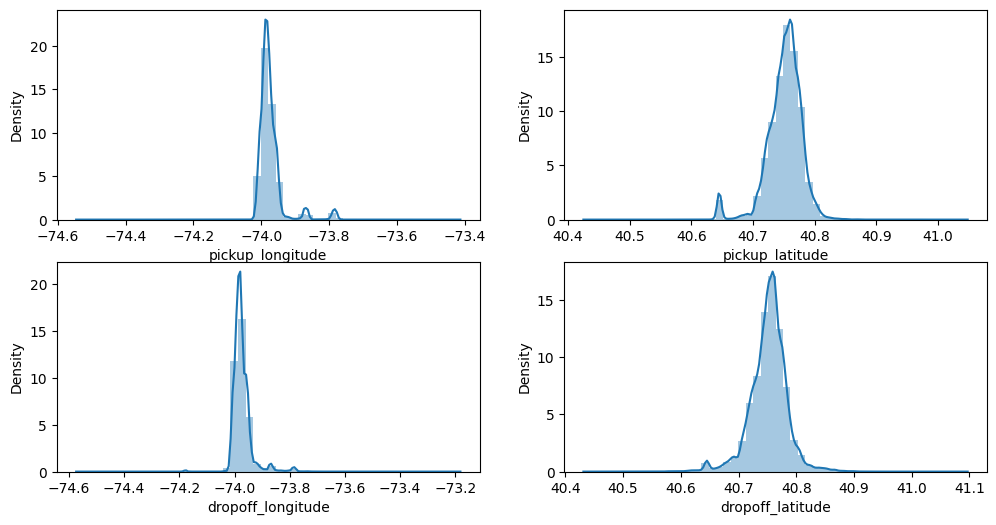

In [20]:
fig, axes = plt.subplots(2,2, figsize=(12,6))
sns.distplot(train['pickup_longitude'], ax=axes[0][0])  #pickup
sns.distplot(train['pickup_latitude'], ax=axes[0][1])  
sns.distplot(train['dropoff_longitude'], ax=axes[1][0])  #dropoff 
sns.distplot(train['dropoff_latitude'], ax=axes[1][1])

- 전체 범위에서 특정 경도와 위도에 쏠려있는 분포임
- 제한된 구역내에서 대부분의 주행이 발생했다는 의미

##### 2) 기타 연속형 변수의 분포 확인
    - Feature: passenger_count
    - Target: trip_duration

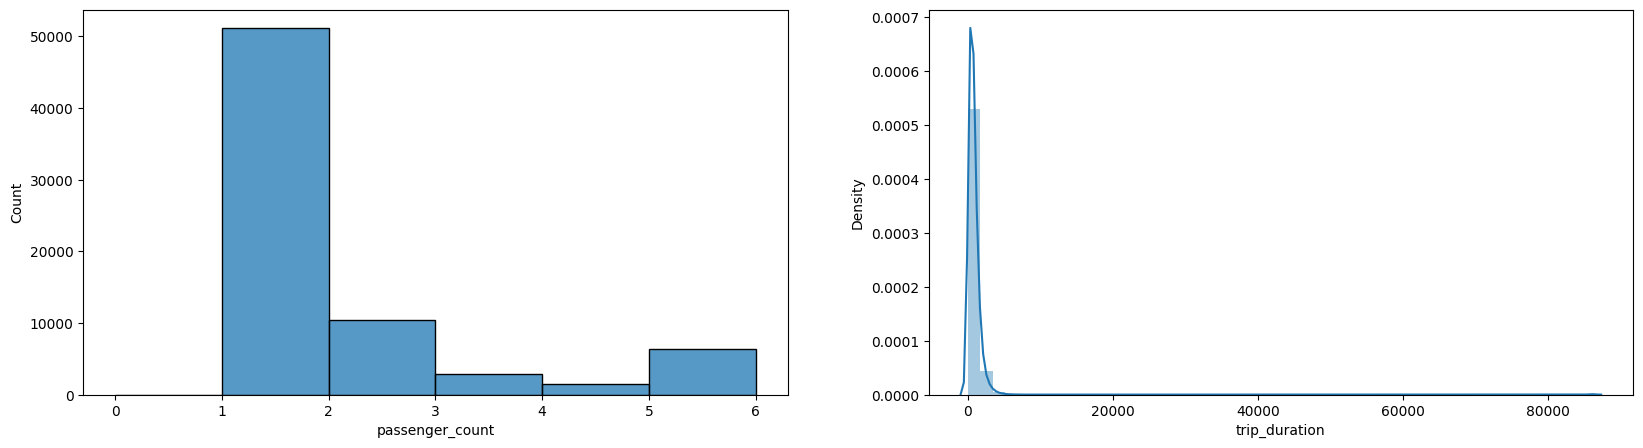

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# passenger_count
sns.histplot(x = train['passenger_count'], bins=6, ax=axes[0]) #데이타가 정수값만 있으므로 histplot이 적절

#trip_duration: target변수 분포 확인
sns.distplot(train['trip_duration'], ax=axes[1])

plt.show()

<Axes: ylabel='Density'>

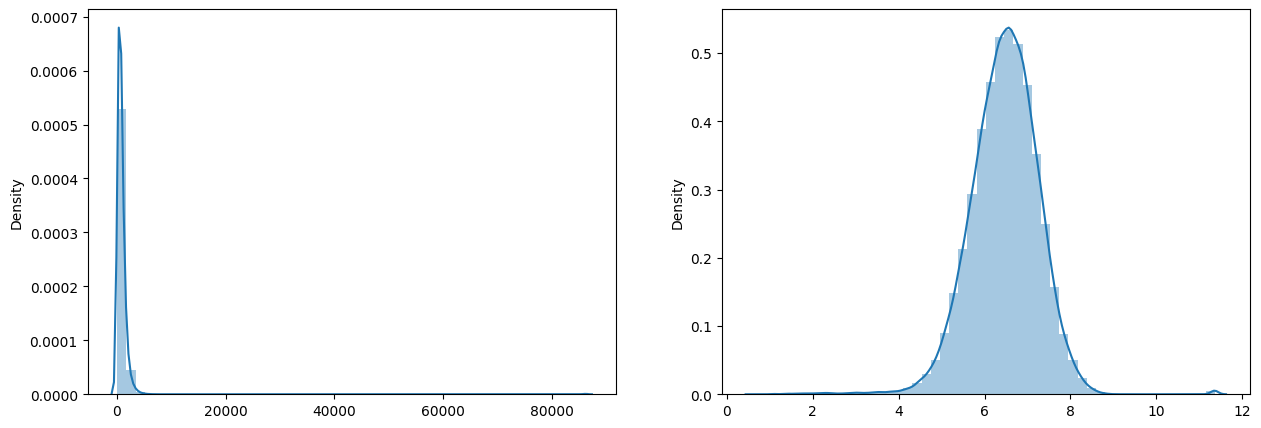

In [22]:
# target값의 원데이터와 로그변환데이터의 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.distplot(x = train['trip_duration'], ax=axes[0])
sns.distplot(x = np.log1p(train['trip_duration']), ax=axes[1])

##### [정리]
- Target
    - 로그 변환 후, 분포 왜곡도가 완화됨  --> **로그 변환**

#### 3) 범주형 (질적) 변수의 빈도를 보여주는 countplot
- vendor_id, store_and_fwd_flag

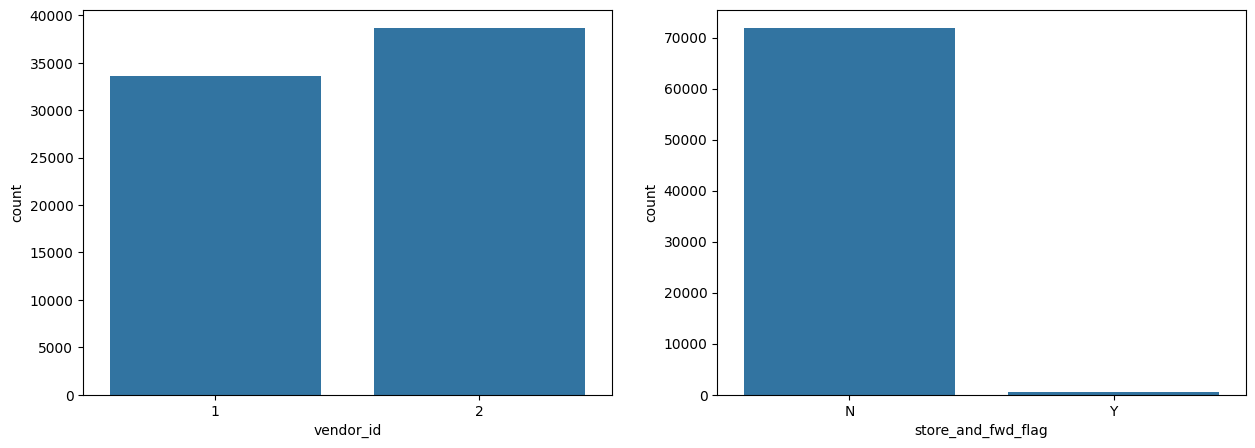

In [23]:
# 범주형 변수의 분포확인
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.countplot(x = train['vendor_id'], ax=axes[0])
sns.countplot(x = train['store_and_fwd_flag'], ax=axes[1])
plt.show()

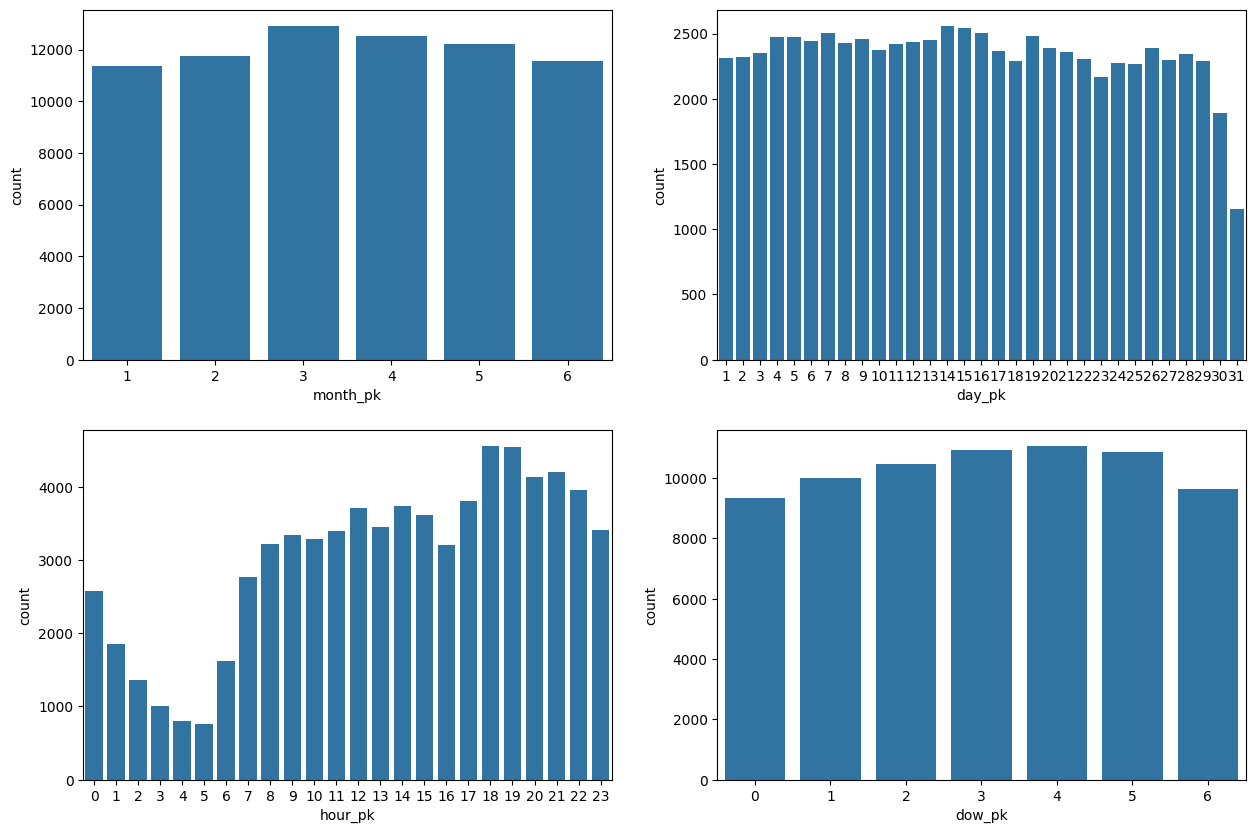

In [24]:
# 범주형 변수의 분포확인(2)
fig, axes = plt.subplots(2, 2, figsize=(15,10))

sns.countplot(x = train['month_pk'], ax=axes[0][0])
sns.countplot(x = train['day_pk'], ax=axes[0][1])
sns.countplot(x = train['hour_pk'], ax=axes[1][0])
sns.countplot(x = train['dow_pk'], ax=axes[1][1])
plt.show()

### (4) 추가 변수 생성
- pick_up 및 drop_off의 위도 및 경도 좌표가 있으므로 (직선) **주행거리**를 나타내는 **신규 변수의 생성**이 가능
- 두 좌표(x1,y1),(x2,y2)간 거리(distance)를 구하려면?
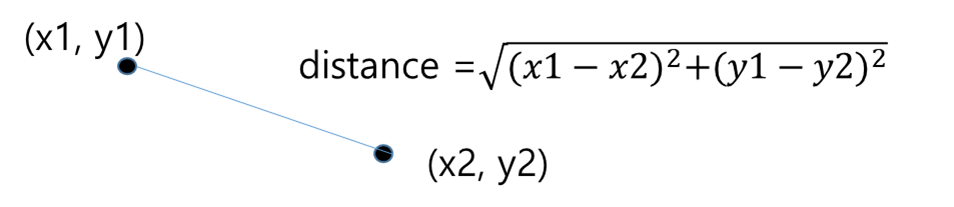

In [25]:
#train 셋 
dist_long = train['pickup_longitude'] - train['dropoff_longitude'] #경도차
dist_lat = train['pickup_latitude'] - train['dropoff_latitude'] #위도차

train['distance'] = np.sqrt(dist_long**2 + dist_lat**2)

In [26]:
#test 셋
dist_long2 = test['pickup_longitude'] - test['dropoff_longitude']
dist_lat2 = test['pickup_latitude'] - test['dropoff_latitude']

test['distance'] = np.sqrt(dist_long2**2 + dist_lat2**2)

<Axes: ylabel='Density'>

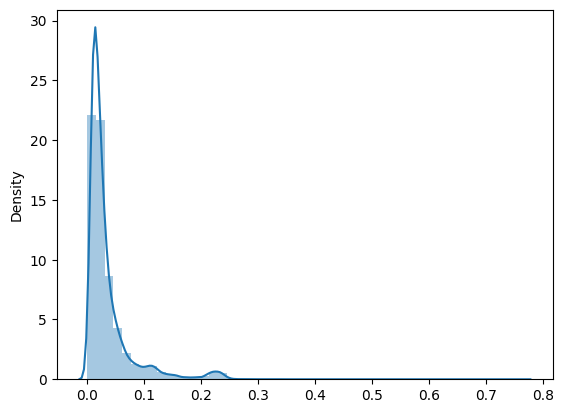

In [27]:
#distance의 분포 확인
sns.distplot(x=train['distance'])

##### [정리] 
- distance도 standardscaling

## [step3] 데이터 전처리

### (1) 중복값 처리 **(Train셋만)**

In [28]:
# train 셋의 중복값 확인
train.duplicated().sum()

0

### (2) 불필요한 Feature삭제 (ID 등)

In [29]:
# id는 사용하지 않으므로 drop
train.drop(['id'], inplace=True, axis=1)
test.drop(['id'], inplace=True, axis=1)

### (3) 결측치 처리
- df.info()를 통해 train과 test 데이터에 결측치가 없음을 이미 확인 했음
- 추가적으로 아래 방법으로도 확인 가능

In [30]:
train.isnull().sum()

vendor_id             0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
month_pk              0
day_pk                0
hour_pk               0
dow_pk                0
distance              0
dtype: int64

In [31]:
test.isnull().sum()

vendor_id             0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
month_pk              0
day_pk                0
hour_pk               0
dow_pk                0
distance              0
dtype: int64

### (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**

#### 1) target  아웃라이어 제거

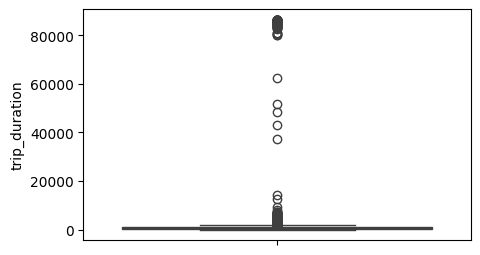

In [32]:
# boxplotting을 통해 outlier 존재여부 확인
plt.figure(figsize=(5,3))
sns.boxplot(y='trip_duration',data=train)   
plt.show()

- MAX값을 넘어가는 아웃라이어가 확인됨
- **아웃라이어 제거 방법**
    - 1) 사분위수 범위(IQR = Q3-Q1)을 계산
    - 2) **Q1-1.5IQR**과 **Q3+1.5IQR**을 각각 max와 min으로 설정
    - 3) [min, max]를 벗어나는 데이터는 아웃라이어로 간주하여 제거

In [33]:
# 1) 사분위수 범위(IQR = Q3-Q1)을 계산
Q1 = train['trip_duration'].quantile(0.25)
Q3 = train['trip_duration'].quantile(0.75)
print("min:{}, Q1:{}, Q3:{}, max:{}".format(train['trip_duration'].min(), Q1,Q3, train['trip_duration'].max()))

min:1, Q1:395.0, Q3:1075.0, max:86387


- maximum값이 상대적으로 지나치게 커서 boxplotting 결과가 상기와 같음

In [34]:
IQR = Q3 - Q1

#2) Q1-1.5IQR과 Q3+1.5IQR을 각각 max와 min으로 설정
MIN = Q1 - 1.5 * IQR
MAX = Q3 + 1.5 * IQR

# 3) [min, max]를 벗어나는 데이터는 이상치로 간주하여 제거
train=train[(MIN<train['trip_duration'])&(train['trip_duration']<MAX)]
train

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,month_pk,day_pk,hour_pk,dow_pk,distance
0,1,1,-73.978401,40.762859,-73.978424,40.762867,N,4,1,18,11,0,0.000024
1,1,1,-74.031891,40.726780,-74.031891,40.726780,N,35,1,6,21,2,0.000000
2,2,1,-73.781883,40.644836,-73.781807,40.644859,N,33,2,21,23,6,0.000080
3,1,1,-73.968071,40.759148,-73.967476,40.759983,N,32,2,8,0,0,0.001026
4,1,1,-73.951538,40.781155,-73.951530,40.781155,N,20,6,26,13,6,0.000008
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69374,2,3,-73.790733,40.644032,-73.914040,40.696590,N,2050,1,26,19,1,0.134041
69376,2,1,-73.862823,40.768478,-73.990959,40.764236,N,2088,3,10,20,3,0.128206
69379,2,1,-73.970619,40.784191,-73.970306,40.783859,N,2035,1,3,16,6,0.000456
69388,2,1,-73.863701,40.769779,-73.987831,40.745869,N,2041,6,1,11,2,0.126412


#### 2) feature별 아웃라이어 제거

In [35]:
# 1) 
Q1 = train['distance'].quantile(0.25)
Q3 = train['distance'].quantile(0.75)
IQR = Q3 - Q1
MIN = Q1 - 1.5 * IQR
MAX = Q3 + 1.5 * IQR
train=train[(MIN<train['distance'])&(train['distance']<MAX)]

- 아웃라이어 제거 후, train data의 건수 줄어듦

### (5) Feature, Target 설정
- train 셋: Feature / Target 으로 분리
- test 셋: Feature만 설정

In [36]:
# train set - features 설정
Xtrain=train.drop(['trip_duration'], axis=1)
Xtrain

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,month_pk,day_pk,hour_pk,dow_pk,distance
0,1,1,-73.978401,40.762859,-73.978424,40.762867,N,1,18,11,0,0.000024
1,1,1,-74.031891,40.726780,-74.031891,40.726780,N,1,6,21,2,0.000000
2,2,1,-73.781883,40.644836,-73.781807,40.644859,N,2,21,23,6,0.000080
3,1,1,-73.968071,40.759148,-73.967476,40.759983,N,2,8,0,0,0.001026
4,1,1,-73.951538,40.781155,-73.951530,40.781155,N,6,26,13,6,0.000008
...,...,...,...,...,...,...,...,...,...,...,...,...
69356,2,1,-73.992088,40.729149,-73.968117,40.786900,N,6,24,12,4,0.062528
69358,2,2,-73.944595,40.834660,-73.963799,40.774448,N,2,26,8,4,0.063199
69361,1,1,-73.997063,40.737560,-73.955826,40.737789,N,1,23,1,5,0.041238
69365,1,1,-73.993462,40.749836,-73.953888,40.775051,N,5,16,18,0,0.046924


In [37]:
# train set -- target 설정
ytrain=train['trip_duration']
ytrain

0           4
1          35
2          33
3          32
4          20
         ... 
69356    2065
69358    2067
69361    2036
69365    2011
69379    2035
Name: trip_duration, Length: 63203, dtype: int64

In [38]:
# test set - feature만 있음
Xtest=test.copy()
Xtest

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,month_pk,day_pk,hour_pk,dow_pk,distance
0,2,1,-73.940033,40.805439,-73.937943,40.804508,N,6,6,8,0,0.002288
1,1,1,-73.986092,40.757153,-73.986023,40.757294,N,6,12,2,6,0.000157
2,1,1,-73.978821,40.747700,-73.977631,40.747272,N,1,7,16,3,0.001265
3,2,5,-73.963753,40.771172,-73.967468,40.772034,N,5,17,19,1,0.003814
4,2,1,-74.347069,40.708519,-74.347069,40.708523,N,5,22,3,6,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...
25250,2,6,-74.002724,40.760632,-73.952957,40.777519,N,3,4,8,4,0.052554
25251,2,1,-73.954643,40.769554,-73.951248,40.774139,N,2,23,15,1,0.005705
25252,2,2,-73.987083,40.733116,-73.963783,40.756920,N,4,9,0,5,0.033309
25253,2,1,-73.781990,40.644722,-73.980675,40.724918,N,5,12,13,3,0.214259


In [39]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63203 entries, 0 to 69379
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   vendor_id           63203 non-null  int64  
 1   passenger_count     63203 non-null  int64  
 2   pickup_longitude    63203 non-null  float64
 3   pickup_latitude     63203 non-null  float64
 4   dropoff_longitude   63203 non-null  float64
 5   dropoff_latitude    63203 non-null  float64
 6   store_and_fwd_flag  63203 non-null  object 
 7   month_pk            63203 non-null  int32  
 8   day_pk              63203 non-null  int32  
 9   hour_pk             63203 non-null  int32  
 10  dow_pk              63203 non-null  int32  
 11  distance            63203 non-null  float64
dtypes: float64(5), int32(4), int64(2), object(1)
memory usage: 5.3+ MB


In [40]:
Xtest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25255 entries, 0 to 25254
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   vendor_id           25255 non-null  int64  
 1   passenger_count     25255 non-null  int64  
 2   pickup_longitude    25255 non-null  float64
 3   pickup_latitude     25255 non-null  float64
 4   dropoff_longitude   25255 non-null  float64
 5   dropoff_latitude    25255 non-null  float64
 6   store_and_fwd_flag  25255 non-null  object 
 7   month_pk            25255 non-null  int32  
 8   day_pk              25255 non-null  int32  
 9   hour_pk             25255 non-null  int32  
 10  dow_pk              25255 non-null  int32  
 11  distance            25255 non-null  float64
dtypes: float64(5), int32(4), int64(2), object(1)
memory usage: 1.9+ MB


- Xtrain, Xtest 셋 모두 14개의 feature를 가짐

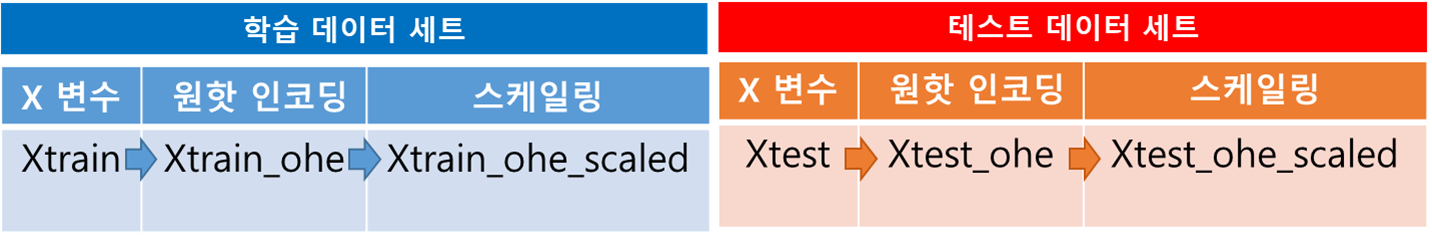

### (6) 원핫 인코딩 **(feature-질적변수만)**
- pd.get_dummies(df, columns[해당 column명])
- 범주형 변수에 대해서 수행

In [41]:
Xtrain_ohe = pd.get_dummies(Xtrain, columns = ['vendor_id','store_and_fwd_flag','month_pk','day_pk','hour_pk','dow_pk'])
Xtest_ohe = pd.get_dummies(Xtest, columns = ['vendor_id','store_and_fwd_flag','month_pk','day_pk','hour_pk','dow_pk'])

In [42]:
Xtrain_ohe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63203 entries, 0 to 69379
Data columns (total 78 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   passenger_count       63203 non-null  int64  
 1   pickup_longitude      63203 non-null  float64
 2   pickup_latitude       63203 non-null  float64
 3   dropoff_longitude     63203 non-null  float64
 4   dropoff_latitude      63203 non-null  float64
 5   distance              63203 non-null  float64
 6   vendor_id_1           63203 non-null  bool   
 7   vendor_id_2           63203 non-null  bool   
 8   store_and_fwd_flag_N  63203 non-null  bool   
 9   store_and_fwd_flag_Y  63203 non-null  bool   
 10  month_pk_1            63203 non-null  bool   
 11  month_pk_2            63203 non-null  bool   
 12  month_pk_3            63203 non-null  bool   
 13  month_pk_4            63203 non-null  bool   
 14  month_pk_5            63203 non-null  bool   
 15  month_pk_6            63

In [43]:
Xtest_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25255 entries, 0 to 25254
Data columns (total 78 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   passenger_count       25255 non-null  int64  
 1   pickup_longitude      25255 non-null  float64
 2   pickup_latitude       25255 non-null  float64
 3   dropoff_longitude     25255 non-null  float64
 4   dropoff_latitude      25255 non-null  float64
 5   distance              25255 non-null  float64
 6   vendor_id_1           25255 non-null  bool   
 7   vendor_id_2           25255 non-null  bool   
 8   store_and_fwd_flag_N  25255 non-null  bool   
 9   store_and_fwd_flag_Y  25255 non-null  bool   
 10  month_pk_1            25255 non-null  bool   
 11  month_pk_2            25255 non-null  bool   
 12  month_pk_3            25255 non-null  bool   
 13  month_pk_4            25255 non-null  bool   
 14  month_pk_5            25255 non-null  bool   
 15  month_pk_6         

- 원핫 인코딩 이후 feature 증가

### (7) 스케일링 **(feature-양적변수만)**
- 스케일링을 통해 변수들의 데이터 분포나 범위를 조정

**[주의] 스케일링 시 주의사항**
- fit (스케일링을 위한 계산 수행): train data
- transform(적용): train data & test data 

In [44]:
from sklearn.preprocessing import MinMaxScaler

#object 선언
minmax_scaler = MinMaxScaler()

In [45]:
#scaling된 데이터프레임을 별도 생성 - train셋
Xtrain_ohe_scaled = pd.DataFrame(data=minmax_scaler.fit_transform(Xtrain_ohe),
                                 columns=Xtrain_ohe.columns,
                                 index=Xtrain_ohe.index)
Xtrain_ohe_scaled

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance,vendor_id_1,vendor_id_2,store_and_fwd_flag_N,store_and_fwd_flag_Y,...,hour_pk_21,hour_pk_22,hour_pk_23,dow_pk_0,dow_pk_1,dow_pk_2,dow_pk_3,dow_pk_4,dow_pk_5,dow_pk_6
0,0.0,0.500922,0.543523,0.499345,0.537565,0.000355,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.452685,0.483921,0.451277,0.477170,0.000000,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.678140,0.348554,0.676107,0.340069,0.001171,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.510238,0.537391,0.509188,0.532738,0.015084,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.525147,0.573746,0.523523,0.568171,0.000112,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69356,0.0,0.488579,0.487835,0.508611,0.577785,0.919525,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
69358,0.2,0.531408,0.662134,0.512494,0.556947,0.929393,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
69361,0.0,0.484093,0.501730,0.519661,0.495595,0.606429,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
69365,0.0,0.487341,0.522009,0.521403,0.557956,0.690056,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
#scaling된 데이터프레임을 별도 생성 - test셋
Xtest_ohe_scaled = pd.DataFrame(data=minmax_scaler.transform(Xtest_ohe),
                                 columns=Xtest_ohe.columns,
                                 index=Xtest_ohe.index)
Xtest_ohe_scaled

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance,vendor_id_1,vendor_id_2,store_and_fwd_flag_N,store_and_fwd_flag_Y,...,hour_pk_21,hour_pk_22,hour_pk_23,dow_pk_0,dow_pk_1,dow_pk_2,dow_pk_3,dow_pk_4,dow_pk_5,dow_pk_6
0,0.0,0.535522,0.613863,0.535739,0.607255,0.033651,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.493987,0.534095,0.492513,0.528237,0.002308,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.500544,0.518480,0.500058,0.511466,0.018596,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.8,0.514132,0.557254,0.509194,0.552906,0.056091,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.168460,0.453755,0.167928,0.446615,0.000056,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25250,1.0,0.478988,0.539843,0.522240,0.562087,0.772843,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
25251,0.0,0.522347,0.554582,0.523777,0.556430,0.083902,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
25252,0.2,0.493092,0.494388,0.512507,0.527612,0.489840,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25253,0.0,0.678044,0.348365,0.497322,0.474055,3.150846,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


##### target 로그 변환

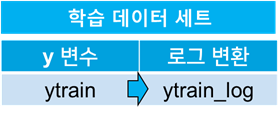

In [47]:
ytrain_log=np.log1p(ytrain)

In [48]:
# 로그 변환 전후의 최대값을 비교함으로써, 로그 변환 후 scale down을 확인
print(ytrain.max())
print(ytrain_log.max())

2093
7.646831391430482


## [step4] 모델 설계 
 - 모델의 선택 및 학습, 예측, 평가 분석 모델 설계
 - 다양한 모델의 성능비교 실시 
    - 선형 모델 - LinearRegression 
    - 트리기반 회귀모델 - DecisionTreeRegressor
    - 트리기반 앙상블 모델 (배깅 기법) - RandomForestRegressor, ExtraTreesRegressor
    - 트리기반 앙상블 모델 (부스팅 기법) - XGBRegressor, LGBMRegressor

- 성능을 평가하기 위해 학습 데이터셋에서 20%를 활용해 검증 데이터셋을 생성
 - test_size = 0.2
 - random_state = 0

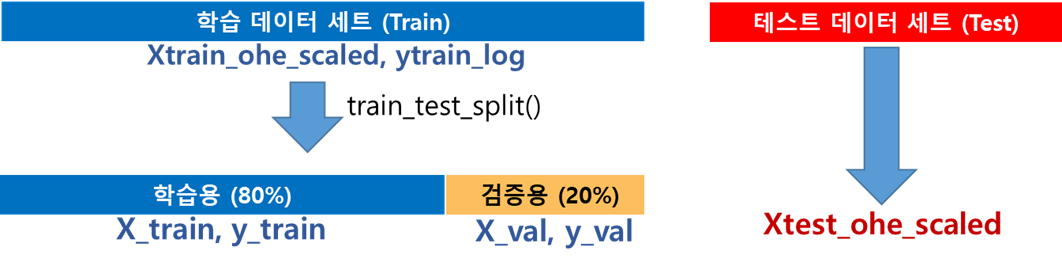

### (1) 훈련 및 검증 데이터 분할

In [49]:
# 데이터 분할: test_size=0.2, random_state=0

X_train, X_val, y_train, y_val = train_test_split(Xtrain_ohe_scaled, ytrain_log, test_size=0.2, random_state=0)

### 4-2) 분석 모델 성능 비교

### (2) 평가지표 확인
- 평가지표가 RMSLE이므로 해당 함수를 작성함

In [50]:
#실제값과 예측값의 log(x+1)값을 입력값으로 root_mean_scared_error를 구하는 함수 작성

def rmsle(log1p_actual, log1p_pred):
    squared_error = (log1p_actual-log1p_pred)**2   
    return np.sqrt(np.mean(squared_error))     

### (3) 알고리즘별 학습, 예측, 평가 

In [51]:
# for문을 이용하여 작성
# 1) Linear Regression ~ 6) LGBM Regressor

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Extra Trees Regressor': ExtraTreesRegressor(),
    'XGB Regressor' : XGBRegressor(verbose=-1),
    'LGBM Regressor' : LGBMRegressor(verbose=-1)
}

# 초기화: selected_estimator, pre_rmsle
selected_estimator = None
min_rmsle = float('inf')

# 모델 학습 및 평가
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_val)
    rmsle_ = rmsle(y_val, pred)
    print(f'[{name} 모델의 rmsle ]: {round(rmsle_, 3)}')

    if rmsle_ < min_rmsle:
        selected_estimator = estimator
        min_rmsle = rmsle_
        print(f'selected estimator: {name}')
    print('')

[Linear Regression 모델의 rmsle ]: 0.478
selected estimator: Linear Regression

[Decision Tree Regression 모델의 rmsle ]: 0.558

[Random Forest 모델의 rmsle ]: 0.396
selected estimator: Random Forest

[Extra Trees Regressor 모델의 rmsle ]: 0.409

[XGB Regressor 모델의 rmsle ]: 0.388
selected estimator: XGB Regressor



  File "C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[LGBM Regressor 모델의 rmsle ]: 0.385
selected estimator: LGBM Regressor



**[정리] 가장 성능이 좋은 모델을 최종 선정** 

### (4) 하이퍼 파라미터 튜닝
- 선정된 모델의 하이퍼파라미터 튜닝
- 본 예제에서는 데이터가 많아 시간이 너무 오래 걸리므로 이 단계를 생략함 
- 만약 진행한다면 scoring을 다음과 같이 사용함
    - scoring=make_scorer(rmsle, greater_is_better=True)

## [step5] 모델 선택 및 적용
### (1) test data의 예측값 생성 
- 선정된 모델로 test data 예측

In [52]:
pred_test = selected_estimator.predict(Xtest_ohe_scaled)

#하이퍼 파라미터 튜닝을 했다면
#pred_test = grid_reg.best_estimator_.predict(Xtest_ohe_scaled)

In [53]:
pred_test

array([5.00521914, 3.86862153, 5.09891302, ..., 6.56451711, 7.07585475,
       6.30254648])

### (2) 예측값 스케일 복구 (로그 변환 등으로 필요시)

In [54]:
pred_test =np.expm1(pred_test)
pred_test

array([ 148.18977232,   46.87634459,  162.84371515, ...,  708.46922069,
       1182.05428328,  544.96041706])

### (3) 실제값과 예측값의 분포 비교

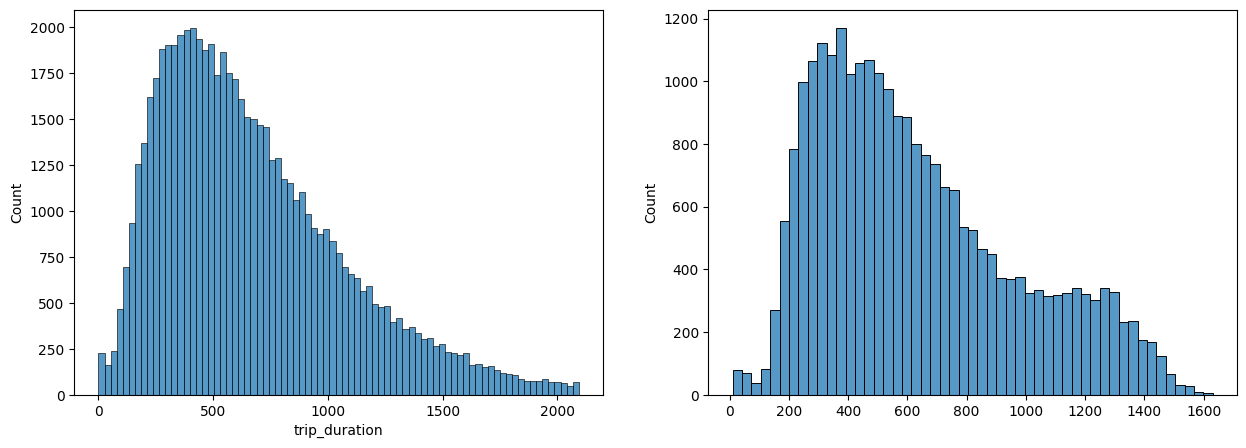

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(x=ytrain, ax=axes[0]) # 실제값 
sns.histplot(x=pred_test, ax=axes[1])  # 예측값
plt.show()

- target의 실제값과 예측값의 분포가 유사함을 확인

## [step6] 결과 파일 생성 
### (1) 예시 파일 불러오기 

In [56]:
submission = pd.read_csv('./data/sample_submission.csv')

In [57]:
submission.head()

,id,trip_duration
0,id1846565,NaN
1,id2473446,NaN
2,id3852188,NaN
3,id3728770,NaN
4,id3733479,NaN


### (2) 예측 결과 저장

In [58]:
#test data의 예측 결과 저장하기
submission['trip_duration'] = pred_test
submission.head()

,id,trip_duration
0,id1846565,148.189772
1,id2473446,46.876345
2,id3852188,162.843715
3,id3728770,192.771006
4,id3733479,50.054969


### (3) 제출할 csv파일 생성

In [59]:
# submission을 csv 파일로 저장
submission.to_csv('./data/MySubmission.csv', index=False)

- 방금 생성된 MySubmission.csv를 제출하여 score를 확인합니다.